## Plot composite reflectivity

- composite reflectivity from SEA-POL /huracan/tank4/cornell/ORCESTRA/sea-pol/qc_data/level4v1.2/PICCOLO_level4_composite_2D.nc

In [1]:
import geopy.distance
import cartopy
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import rc, colors
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap,Normalize
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
#import cmweather
import seaborn as sns
import numpy as np
import xarray as xr
import pandas as pd
from scipy.interpolate import interp2d, RectBivariateSpline
from datetime import datetime, timedelta
import cftime
import json
import glob
import os

In [2]:
coordinates = {'bcoNorth': 13.15, 'bcoEast': -59.42} 

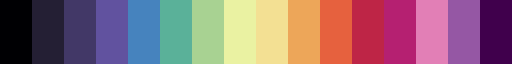

In [3]:
# Load colormap

# Read the colormap from a .txt file
def load_colormap_from_txt(file_path):
    # Load RGB values from the file
    rgb_values = np.loadtxt(file_path)
    return ListedColormap(rgb_values)

# Example usage
colormap_file = 'chase-spectral-rgb.txt'  # Replace with your .txt file path
radar_cmap = load_colormap_from_txt(colormap_file)

discrete_cmap = ListedColormap(radar_cmap(np.linspace(0, 1, 16)))
discrete_mask_cmap = discrete_cmap.copy()
discrete_mask_cmap.set_under(color='white') #set values below vmin to white
discrete_mask_cmap.set_bad(color='gray') #set missing (NaN) values to gray

discrete_mask_cmap

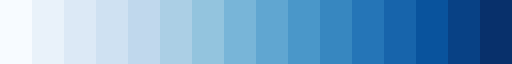

In [4]:
rain_cmap=plt.get_cmap('Blues').copy()
rain_cmap = ListedColormap(rain_cmap(np.linspace(0, 1, 16)))
rain_cmap.set_under(color='white') #set values below vmin to white
rain_cmap.set_over(color='red') #set values above vmax to blue
rain_cmap.set_bad(color='gray') #set missing (NaN) values to gray

rain_cmap

Define time period of case study

In [61]:
#Define time period
time_map1 = np.datetime64('2024-09-23T06:00')
time_map2 = np.datetime64('2024-09-23T16:00')

SEA-POL reflectivity

In [62]:
#Load data
seapol = xr.open_dataset('/huracan/tank4/cornell/ORCESTRA/sea-pol/qc_data/level4v1.2/PICCOLO_level4_composite_2D.nc')
#seapol = xr.open_dataset("ipfs://bafybeigdehy7635uypwipv5xdnlvgnlbncvuyudajwejawn2llirbp2vyq", engine="zarr")

#Find indices
index_map1 = np.abs(pd.to_datetime(seapol.time) - time_map1).argmin()
index_map2 = np.abs(pd.to_datetime(seapol.time) - time_map2).argmin()

map1 = seapol.DBZ[index_map1,:,:]
map2 = seapol.DBZ[index_map2,:,:]

SEA-POL low-level rain rate

In [7]:
#Load data
rain = xr.open_dataset('/huracan/tank4/cornell/ORCESTRA/sea-pol/qc_data/level4v1.2/PICCOLO_level4_rainrate_2D.nc')

SEA-POL QVP

In [ ]:
#load data
qvp = xr.open_dataset('/huracan/tank4/cornell/ORCESTRA/sea-pol/qc_data/level4v1.2/PICCOLO_level4_qvp_1D.nc')

Plot qvp time series

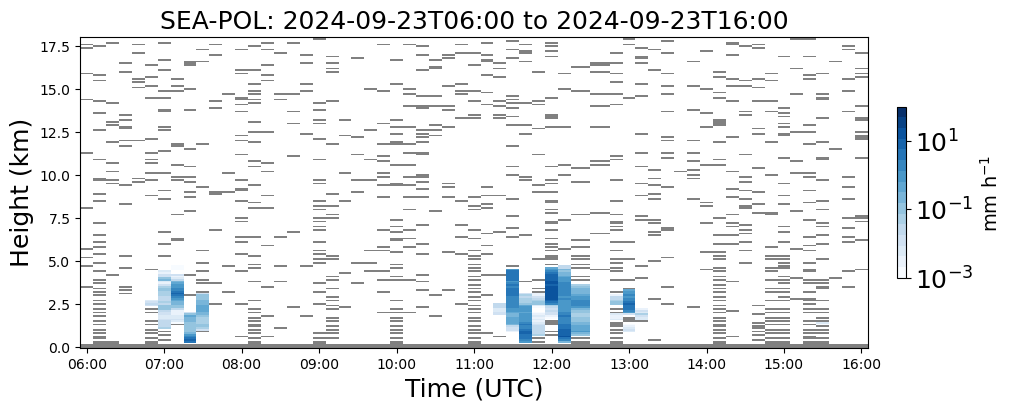

In [64]:
#extract data at the right times
rain_qvp = qvp.RAINRATE.sel(time=slice(time_map1, time_map2))

#set -9999 values to zero
rain_qvp = rain_qvp.where(rain_qvp != -9999, 1e-9)

#plot
fig, axs = plt.subplots(figsize=(10, 4), layout="constrained")
cax = axs.pcolormesh(
    rain_qvp.time.values,
    (rain_qvp.Z / 1000).values,
    rain_qvp.values.T,
    cmap=rain_cmap,
    norm=colors.LogNorm(vmin=0.001, vmax=100),
    shading='nearest',
)

cbar = fig.colorbar(cax, ax=axs, orientation='vertical', pad=0.02, shrink=0.55)
cbar.ax.tick_params(labelsize=18)
cbar.set_label('mm h$^{-1}$', fontsize=14)

axs.set_title('SEA-POL: ' + str(time_map1) + ' to ' + str(time_map2), fontsize=18)
axs.set_ylabel('Height (km)', fontsize=18)
axs.set_xlabel('Time (UTC)', fontsize=18)
axs.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

### Plot individual radar frames

In [ ]:
# loop between time_map1 and time_map2 to make a plot for each time step
time_range = pd.date_range(time_map1, time_map2, freq='5 min')
time_range = pd.to_datetime(time_range)

proj = ccrs.PlateCarree()

for i_t, tt in enumerate(time_range):
    #skip to next loop if there is no data at time=tt
    if tt not in seapol.DBZ.time.values:
        continue
    
    fig, axs = plt.subplots(figsize=(8, 8),layout="constrained", subplot_kw={'projection': proj})
    gl = axs.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=1,alpha=0.25)
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 16}
    gl.ylabel_style = {'size': 16}
    
    # plot radar image for time tt
    map_tt = seapol.DBZ.sel(time=tt,X=slice(-20000,20000),Y=slice(-20000,20000))
    cax = axs.pcolormesh(map_tt.longitude, map_tt.latitude, map_tt, cmap=discrete_mask_cmap, vmin=-10, vmax=60,shading='auto')
    
    #add BCO coordinates
    axs.plot(coordinates['bcoEast'], coordinates['bcoNorth'], marker='o', color='black', markersize=8, label='BCO')
    
    axs.coastlines()
    
    axs.set_aspect('equal',adjustable='box')
    cbar = fig.colorbar(cax, ax=axs, orientation='vertical',pad=0.02, shrink=0.55)
    cbar.ax.tick_params(labelsize=18)
    cbar.set_ticks(np.linspace(-10,60,8))
    cbar.ax.set_ylabel('dBZ', fontsize=18)
    
    axs.set_title('SEA-POL: ' + str(tt),fontsize=18)    
    axs.set_ylabel('Latitude', fontsize=18)
    axs.set_xlabel('Longitude',fontsize=18)
    axs.set_xticklabels(axs.get_xticklabels(), fontsize=18)
    axs.set_yticklabels(axs.get_yticklabels(), fontsize=18)

    # Add grid lines
    #axs.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

    # Add 60 km circle
    #axs.add_patch(plt.Circle((map_tt.longitude[245,245], map_tt.latitude[245,245]), 60/111.32, color='gray', alpha = 0.7,fill=False, linestyle='--', linewidth=0.5))
    
    # save frame
    fig.savefig(f"../../figures/BCOcase/frame_{i_t:03d}.png")
    plt.show()
    plt.close()

In [ ]:
# loop between time_map1 and time_map2 to make a plot for each time step
time_range = pd.date_range(time_map1, time_map2, freq='5 min')
time_range = pd.to_datetime(time_range)

for i_t, tt in enumerate(time_range):
    #skip to next loop if there is no data at time=tt
    if tt not in seapol.DBZ.time.values:
        continue
    
    fig, axs = plt.subplots(figsize=(8, 8),layout="constrained")
    # plot radar image for time tt
    map_tt = seapol.DBZ.sel(time=tt,X=slice(-20000,20000),Y=slice(-20000,20000))
    cax = axs.pcolormesh(map_tt.longitude, map_tt.latitude, map_tt, cmap=discrete_mask_cmap, vmin=-10, vmax=60,shading='auto')
    
    #add BCO coordinates
    axs.plot(coordinates['bcoEast'], coordinates['bcoNorth'], marker='o', color='black', markersize=8, label='BCO')
    
    axs.set_aspect('equal',adjustable='box')
    cbar = fig.colorbar(cax, ax=axs, orientation='vertical',pad=0.02, shrink=0.55)
    cbar.ax.tick_params(labelsize=18)
    cbar.set_ticks(np.linspace(-10,60,8))
    cbar.ax.set_ylabel('dBZ', fontsize=18)
    
    axs.set_title('SEA-POL: ' + str(tt),fontsize=18)    
    axs.set_ylabel('Latitude', fontsize=18)
    axs.set_xlabel('Longitude',fontsize=18)
    axs.set_xticklabels(axs.get_xticklabels(), fontsize=18)
    axs.set_yticklabels(axs.get_yticklabels(), fontsize=18)

    # Add grid lines
    axs.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

    # Add 60 km circle
    #axs.add_patch(plt.Circle((map_tt.longitude[245,245], map_tt.latitude[245,245]), 60/111.32, color='gray', alpha = 0.7,fill=False, linestyle='--', linewidth=0.5))
    
    # save frame
    fig.savefig(f"../../figures/BCOcase/frame_{i_t:03d}.png")
    plt.show()
    plt.close()